In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [23]:
df = pd.read_csv("../Data/india_landfill_dataset_ultimate.csv")
df.head(50)

,City,Month,Temperature_C,Rainfall_mm,Humidity_%,Soil_Moisture_%,Soil_Type,Latitude,Longitude,Distance_From_Coast_km,Groundwater_Depth_m
0,Delhi,Jan,29.483571,120.587719,69.209546,43.937482,Alluvial,28.6139,77.2090,937.876496,5
1,Delhi,Feb,26.308678,278.712851,91.379307,60.401841,Alluvial,28.6139,77.2090,937.876496,5
2,Delhi,Mar,30.238443,154.864905,70.581582,45.446247,Alluvial,28.6139,77.2090,937.876496,5
3,Delhi,Apr,34.615149,115.162325,70.837388,44.805679,Alluvial,28.6139,77.2090,937.876496,5
4,Delhi,May,25.829233,69.252304,64.203190,39.906960,Alluvial,28.6139,77.2090,937.876496,5
5,Delhi,Jun,25.829315,115.800150,83.353533,52.328123,Alluvial,28.6139,77.2090,937.876496,5
6,Delhi,Jul,34.896064,110.657452,81.447039,51.081372,Alluvial,28.6139,77.2090,937.876496,5
7,Delhi,Aug,30.837174,54.981537,55.614841,34.468535,Alluvial,28.6139,77.2090,937.876496,5
8,Delhi,Sep,24.652628,62.653423,45.211292,28.379844,Alluvial,28.6139,77.2090,937.876496,5
9,Delhi,Oct,29.712800,132.156871,61.955290,39.816312,Alluvial,28.6139,77.2090,937.876496,5


In [24]:
df.describe()

,Temperature_C,Rainfall_mm,Humidity_%,Soil_Moisture_%,Latitude,Longitude,Distance_From_Coast_km,Groundwater_Depth_m
count,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000
mean,27.109213,121.942194,64.921132,41.391523,20.122367,78.076167,548.567576,6.578947
std,4.893464,83.391677,15.114800,9.274541,1.956800,1.853561,171.827271,4.460624
min,10.793663,2.755139,20.132960,13.068829,12.971600,72.571400,0.000000,5.000000
25%,23.772585,59.662003,54.510470,35.220713,20.000000,78.000000,546.494757,5.000000
50%,27.126503,102.970124,64.979619,41.348505,20.000000,78.000000,546.494757,5.000000
75%,30.246901,161.500723,75.195454,47.446431,20.000000,78.000000,546.494757,5.000000
max,45.000000,500.000000,100.000000,64.814387,28.613900,88.363900,1358.360715,30.000000


In [25]:
df.isna().sum()

City                      0
Month                     0
Temperature_C             0
Rainfall_mm               0
Humidity_%                0
Soil_Moisture_%           0
Soil_Type                 0
Latitude                  0
Longitude                 0
Distance_From_Coast_km    0
Groundwater_Depth_m       0
dtype: int64

<h3><b>Feature Correlation Heatmap

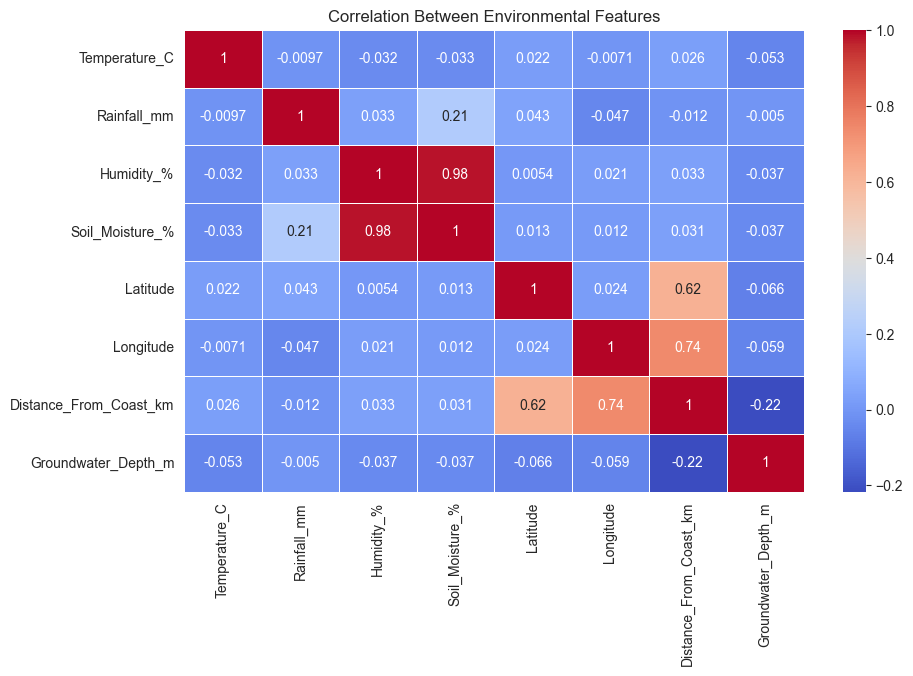

In [40]:
plt.figure(figsize=(10,6))

corr = df.drop(columns=["City","Month","Soil_Type"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Environmental Features")

plt.show()

In [27]:
features = [
"Temperature_C",
"Rainfall_mm",
"Humidity_%",
"Soil_Moisture_%",
"Latitude",
"Longitude",
"Distance_From_Coast_km",
"Groundwater_Depth_m"
]

X = df[features]
y = df["Soil_Type"]
groups = df["City"]

In [28]:
print(X.head())

   Temperature_C  Rainfall_mm  Humidity_%  Soil_Moisture_%  Latitude  \
0      29.483571   120.587719   69.209546        43.937482   28.6139   
1      26.308678   278.712851   91.379307        60.401841   28.6139   
2      30.238443   154.864905   70.581582        45.446247   28.6139   
3      34.615149   115.162325   70.837388        44.805679   28.6139   
4      25.829233    69.252304   64.203190        39.906960   28.6139   

   Longitude  Distance_From_Coast_km  Groundwater_Depth_m  
0     77.209              937.876496                    5  
1     77.209              937.876496                    5  
2     77.209              937.876496                    5  
3     77.209              937.876496                    5  
4     77.209              937.876496                    5  


In [29]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [30]:
model = RandomForestClassifier(
n_estimators=300,
max_depth=10,
random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [31]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9375
              precision    recall  f1-score   support

    Alluvial       1.00      1.00      1.00       168
       Black       0.92      1.00      0.96        12
    Laterite       0.00      0.00      0.00        12
         Red       0.00      0.00      0.00         0

    accuracy                           0.94       192
   macro avg       0.48      0.50      0.49       192
weighted avg       0.93      0.94      0.94       192



c:\Users\rahul\OneDrive\Desktop\Agentic AI–based Decision Support System for Land Filling & Soil Recommendation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rahul\OneDrive\Desktop\Agentic AI–based Decision Support System for Land Filling & Soil Recommendation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rahul\OneDrive\Desktop\Agentic AI–based Decision Support System for Land Filling & Soil Recommendation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: 

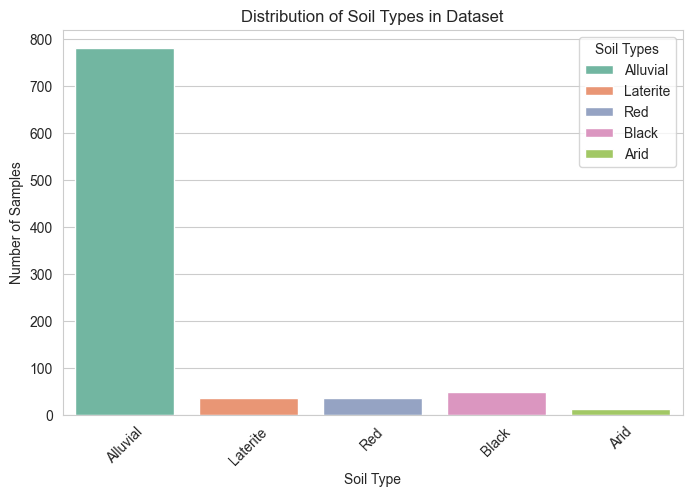

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Soil_Type",
    hue="Soil_Type",
    palette="Set2",
    legend=True
)

plt.title("Distribution of Soil Types in Dataset")
plt.xlabel("Soil Type")
plt.ylabel("Number of Samples")

plt.legend(title="Soil Types")
plt.xticks(rotation=45)

plt.show()

<t><b>This graph shows how many samples exist for each soil type.

C:\Users\rahul\AppData\Local\Temp\ipykernel_11172\2080642471.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Soil Types")


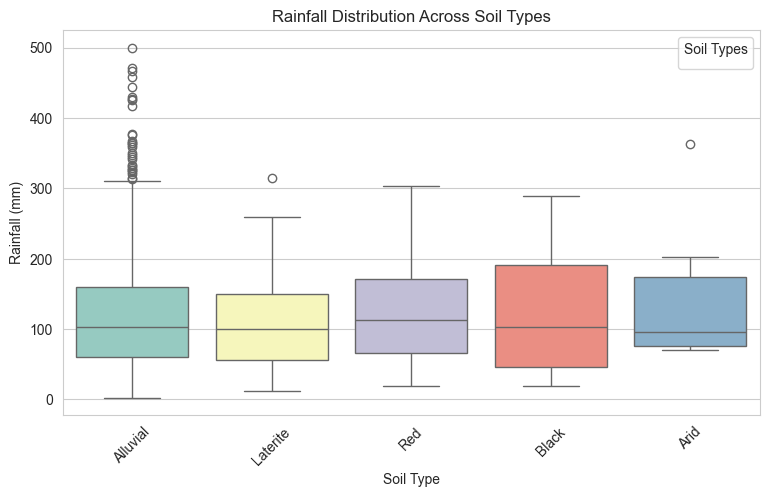

In [37]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="Soil_Type",
    y="Rainfall_mm",
    hue="Soil_Type",
    palette="Set3"
)

plt.title("Rainfall Distribution Across Soil Types")
plt.xlabel("Soil Type")
plt.ylabel("Rainfall (mm)")

plt.legend(title="Soil Types")
plt.xticks(rotation=45)

plt.show()

<t><b>This graph shows how rainfall varies for different soil types.

C:\Users\rahul\AppData\Local\Temp\ipykernel_11172\3036567964.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Soil Types")


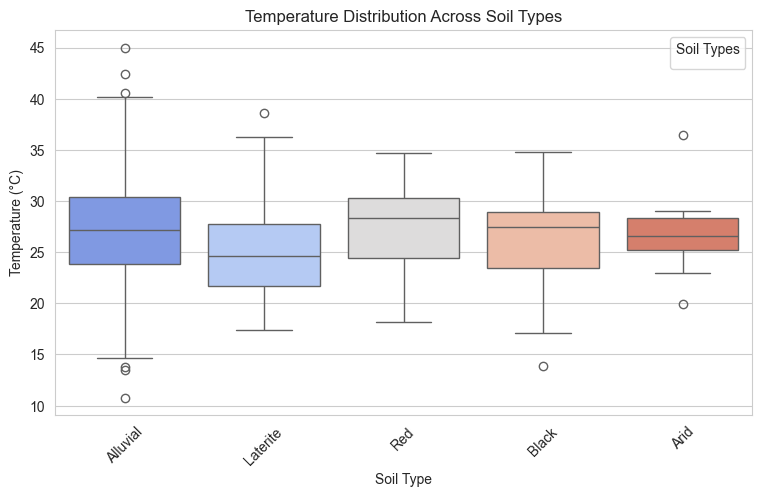

In [38]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="Soil_Type",
    y="Temperature_C",
    hue="Soil_Type",
    palette="coolwarm"
)

plt.title("Temperature Distribution Across Soil Types")
plt.xlabel("Soil Type")
plt.ylabel("Temperature (°C)")

plt.legend(title="Soil Types")
plt.xticks(rotation=45)

plt.show()

<t><b>This graph shows temperature variation across soil types.

<h4>Rainfall vs Soil Moisture

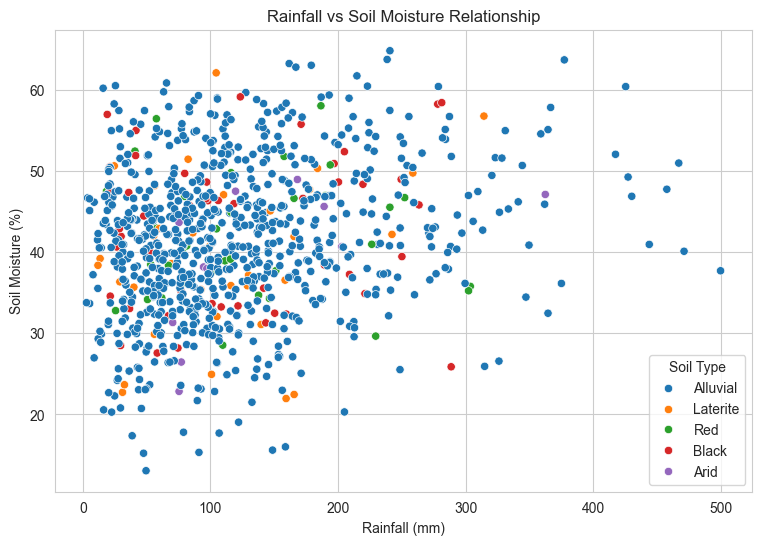

In [39]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Soil_Moisture_%",
    hue="Soil_Type",
    palette="tab10"
)

plt.title("Rainfall vs Soil Moisture Relationship")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Soil Moisture (%)")

plt.legend(title="Soil Type")

plt.show()

<h1><b> Model Metrics Visualization

<h3>It shows how many predictions were correct vs incorrect for each soil type.

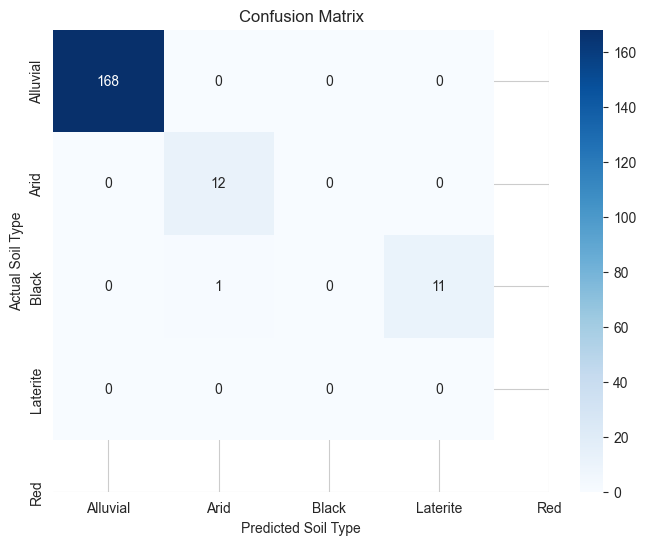

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Soil Type")
plt.ylabel("Actual Soil Type")

plt.show()

<h2><b>Feature Importance Curve

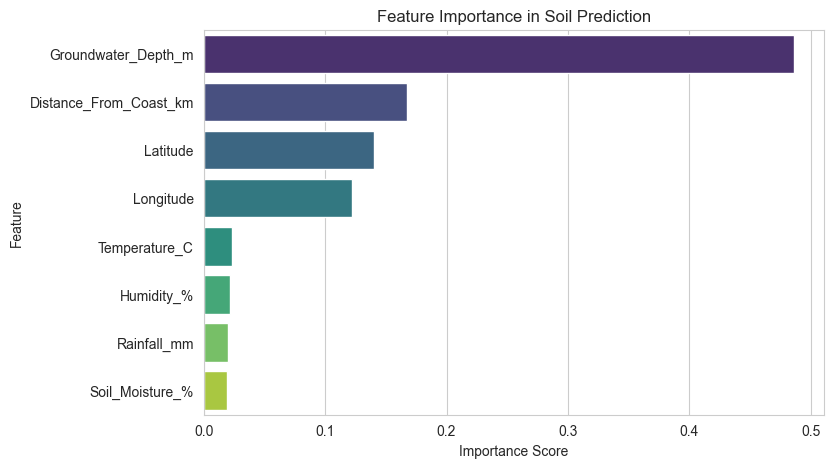

In [42]:
import pandas as pd

importance = model.feature_importances_

features = X_train.columns

imp_df = pd.DataFrame({
    "Feature":features,
    "Importance":importance
}).sort_values("Importance",ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    data=imp_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance in Soil Prediction")

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

<h3><b>ROC Curve

c:\Users\rahul\OneDrive\Desktop\Agentic AI–based Decision Support System for Land Filling & Soil Recommendation\venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\rahul\OneDrive\Desktop\Agentic AI–based Decision Support System for Land Filling & Soil Recommendation\venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


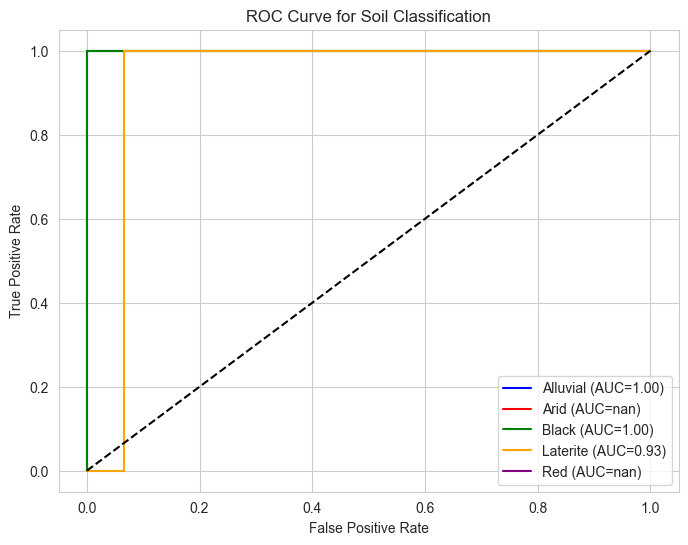

In [43]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import numpy as np

y_test_bin = label_binarize(y_test, classes=model.classes_)

y_score = model.predict_proba(X_test)

plt.figure(figsize=(8,6))

colors = cycle(["blue","red","green","orange","purple"])

for i,color in zip(range(len(model.classes_)),colors):

    fpr,tpr,_ = roc_curve(y_test_bin[:,i],y_score[:,i])
    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        label=f"{model.classes_[i]} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve for Soil Classification")

plt.legend()

plt.show()

<h2><b>Prediction Confidence

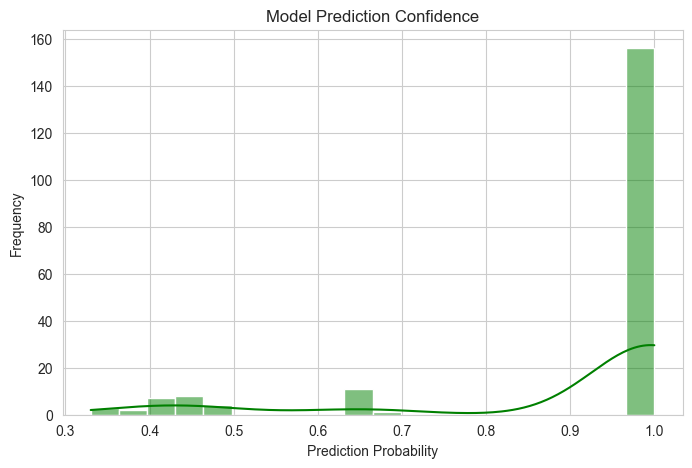

In [44]:
probs = model.predict_proba(X_test).max(axis=1)

plt.figure(figsize=(8,5))

sns.histplot(
    probs,
    bins=20,
    kde=True,
    color="green"
)

plt.title("Model Prediction Confidence")

plt.xlabel("Prediction Probability")
plt.ylabel("Frequency")

plt.show()

<h1><b>Saving our model using JobLib so that we can use it our model further and we do not have to train test all the time.

In [45]:
import joblib

joblib.dump(model, "soil_recommendation_model.pkl")

['soil_recommendation_model.pkl']

In [47]:
joblib.dump(model, "soil_recommendation_model.pkl")

['soil_recommendation_model.pkl']

<h1><b> Lets build the Agent for decision making.

In [48]:
def landfill_suitability(soil, groundwater, rainfall):

    if soil == "Arid" and groundwater > 20:
        return "Suitable"

    if soil == "Alluvial" and groundwater < 10:
        return "Not Suitable"

    return "Moderate"